#**3 - Definição final da variável-alvo *TARGET***

O cliente será classificado como de **maior risco (TARGET = 1)** quando apresentar:

STATUS = 1: de 30 a 59 dias, pelo menos 2 vezes (recorrência de atraso média) no período de 61 meses OU

STATUS >= 2, 60 dias ou mais, pelo menos uma vez no período de 61 meses (gravidade do atraso) OU

STATUS = 0, de 1 a 29 dias pelo menos 6 vezes (recorrência de atraso moderada) no período de 61 meses




**Caso nenhuma dessas condições seja satisfeita, o cliente será classificado como de menor risco (TARGET = 0)**.

# **4 - Análise Exploratória de Dados - application_record**

In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
df_application.shape

(438557, 18)

In [ ]:
#verificando dados em branco
df_application.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [ ]:
#resumo de campos

for coluna in df_application.select_dtypes(include='object').columns:
    print(f'\n===== {coluna} =====')
    print(df_application[coluna].value_counts(dropna=False))


===== CODE_GENDER =====
CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64

===== FLAG_OWN_CAR =====
FLAG_OWN_CAR
N    275459
Y    163098
Name: count, dtype: int64

===== FLAG_OWN_REALTY =====
FLAG_OWN_REALTY
Y    304074
N    134483
Name: count, dtype: int64

===== NAME_INCOME_TYPE =====
NAME_INCOME_TYPE
Working                 226104
Commercial associate    100757
Pensioner                75493
State servant            36186
Student                     17
Name: count, dtype: int64

===== NAME_EDUCATION_TYPE =====
NAME_EDUCATION_TYPE
Secondary / secondary special    301821
Higher education                 117522
Incomplete higher                 14851
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64

===== NAME_FAMILY_STATUS =====
NAME_FAMILY_STATUS
Married                 299828
Single / not married     55271
Civil marriage           36532
Separated                27251
Widow                    19675
Name: count, dty

In [ ]:
#verificar registros duplicados
df_application.duplicated().sum()

np.int64(0)

# **5 - Pré-processamento - application_record**

In [ ]:
#preenchendo campos em branco de ocupação como "not reported"
df_application['OCCUPATION_TYPE'] = df_application['OCCUPATION_TYPE'].fillna('Not reported')
df_application.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [ ]:
#Tratando coluna DAYS_BIRTH
df_application['DAYS_BIRTH'].describe()

,DAYS_BIRTH
count,438557.000000
mean,-15997.904649
std,4185.030007
min,-25201.000000
25%,-19483.000000
50%,-15630.000000
75%,-12514.000000
max,-7489.000000


```
# Observações:
1- DAYS_BIRTH demonstrou totalidade dos valores negativos
```

In [ ]:
#Criando coluna AGE com base na idade em dias DAYS_BIRTH
df_application['AGE'] = (-df_application['DAYS_BIRTH'] / 365.25).round(1)

In [ ]:
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Not reported,2.0,32.9
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Not reported,2.0,32.9
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58.8
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52.3
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52.3


In [ ]:
#Tratando coluna DAYS_EMPLOYED
df_application['DAYS_EMPLOYED'].describe()

,DAYS_EMPLOYED
count,438557.000000
mean,60563.675328
std,138767.799647
min,-17531.000000
25%,-3103.000000
50%,-1467.000000
75%,-371.000000
max,365243.000000


```
# Observações:
1- DAYS_EMPLOYED demonstrou valores mínimos negativos e máximos positivos. Análise relevante antes do tratamento
```

In [ ]:
# verificando quantidade de valores positivos e negativos
(df_application['DAYS_EMPLOYED'] < 0).value_counts()

,count
DAYS_EMPLOYED,
True,363228
False,75329


In [ ]:
#Investigando quais valores são positivos
df_application_positive = df_application[df_application['DAYS_EMPLOYED'] >= 0]
df_application_positive['DAYS_EMPLOYED'].value_counts().head(20)

,count
DAYS_EMPLOYED,
365243,75329


```
# Observações:
1- Todos os valores positivos são DAYS_EMPLOYED = 365243 ou 365243/365,25≈ 1000 anos
```

In [ ]:
#Investigando a profissão dos valores positivos
df_application[df_application['DAYS_EMPLOYED'] == 365243]['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,75329


In [ ]:
pd.crosstab(
    df_application['NAME_INCOME_TYPE'],
    df_application['DAYS_EMPLOYED'] >= 0,
    normalize='index'
) * 100

DAYS_EMPLOYED,False,True
NAME_INCOME_TYPE,,
Commercial associate,100.000000,0.000000
Pensioner,0.217239,99.782761
State servant,100.000000,0.000000
Student,100.000000,0.000000
Working,100.000000,0.000000


```
# Observações:
1- Os valores positivos correspondem aos pensionistas. Criar variável com registros positivos ajustados como ausentes
```



In [ ]:
#criando variável DAYS_EMPLOYED_CLEAN ajustando os valores positivos como ausentes

df_application['DAYS_EMPLOYED_CLEAN'] = df_application['DAYS_EMPLOYED'].where(
    df_application['DAYS_EMPLOYED'] < 0
)
df_application['DAYS_EMPLOYED_CLEAN']

,DAYS_EMPLOYED_CLEAN
0,-4542.0
1,-4542.0
2,-1134.0
3,-3051.0
4,-3051.0
...,...
438552,NaN
438553,-3007.0
438554,-372.0
438555,NaN


In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
#transformar vaiáveis numéricas de dias para anos e deixar os vazios como 60 para demonstrar pensionistas
df_application['YEARS_EMPLOYED'] = (
    -df_application['DAYS_EMPLOYED_CLEAN'] / 365.25
).fillna(60)
df_application[['YEARS_EMPLOYED', 'DAYS_EMPLOYED']].round(1)

,YEARS_EMPLOYED,DAYS_EMPLOYED
0,12.4,-4542
1,12.4,-4542
2,3.1,-1134
3,8.4,-3051
4,8.4,-3051
...,...,...
438552,60.0,365243
438553,8.2,-3007
438554,1.0,-372
438555,60.0,365243


In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
#análise descritiva de anos de emprego
df_application['YEARS_EMPLOYED'].describe()

,YEARS_EMPLOYED
count,438557.000000
mean,16.253923
std,20.799711
min,0.032854
25%,2.992471
50%,6.880219
75%,16.013689
max,60.000000


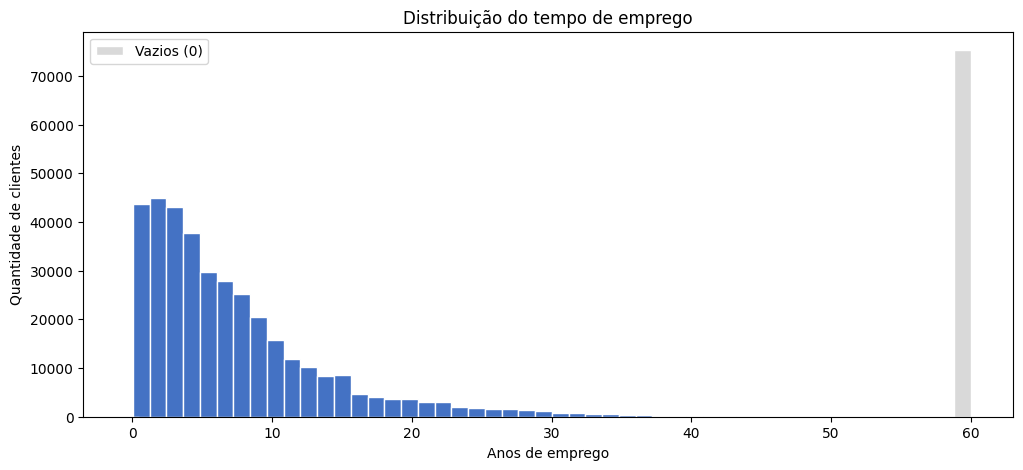

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Valores preenchidos
dados = df_application['YEARS_EMPLOYED'].dropna()

# Quantidade de valores vazios
qtd_vazios = df_application['YEARS_EMPLOYED'].isna().sum()

# Histograma dos valores preenchidos
counts, bins = np.histogram(dados, bins=50)

# Cores das barras
cores = [
    '#D9D9D9' if bin_left >= 50 else '#4472C4'
    for bin_left in bins[:-1]
]

plt.figure(figsize=(12, 5))

# Histograma
plt.bar(
    bins[:-1],
    counts,
    width=np.diff(bins),
    align='edge',
    color=cores,
    edgecolor='white'
)

# Barra dos valores vazios
plt.bar(
    0,
    qtd_vazios,
    width=1,
    color='#D9D9D9',
    edgecolor='white',
    label=f'Vazios ({qtd_vazios:,})'
)

plt.xlabel('Anos de emprego')
plt.ylabel('Quantidade de clientes')
plt.title('Distribuição do tempo de emprego')
plt.legend()

plt.show()

```
# Observações:
1- Concentração em até 10 anos de emprego com os pensionistas separados sem informação
```



# **6 - Pré-processamento - Unir tabelas de dados dos clientes e de informações de TARGET**

In [ ]:
#inner apenas clientes que possuem informações de cadastro + histórico de crédito com TARGET.
df_model = df_application.merge(
    TARGET3[['ID', 'TARGET']],
    on='ID',
    how='inner'
)

In [ ]:
#tamanho da tabela por registros coincidentes
df_model.shape

(36457, 22)

In [ ]:
df_model.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,DAYS_EMPLOYED_CLEAN,YEARS_EMPLOYED,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Not reported,2.0,32.9,-4542.0,12.435318,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Not reported,2.0,32.9,-4542.0,12.435318,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Security staff,2.0,58.8,-1134.0,3.104723,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,52.3,-3051.0,8.353183,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,52.3,-3051.0,8.353183,0


In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

In [ ]:
df_model['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
1,56.921853
0,43.078147


# **7 - Pré-processamento - definindo variáveis do modelo**

In [ ]:
#-excluir a variável ID, DAYS_BIRTH, DAYS_EMPLOYED, DAYS_EMPLOYED_CLEAN e'FLAG_MOBIL (todos os clientes têm celular)  do modelo
df_modela = df_model.drop(columns=['ID', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_EMPLOYED_CLEAN', 'FLAG_MOBIL']).copy()

In [ ]:
df_modela.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CODE_GENDER          36457 non-null  object 
 1   FLAG_OWN_CAR         36457 non-null  object 
 2   FLAG_OWN_REALTY      36457 non-null  object 
 3   CNT_CHILDREN         36457 non-null  int64  
 4   AMT_INCOME_TOTAL     36457 non-null  float64
 5   NAME_INCOME_TYPE     36457 non-null  object 
 6   NAME_EDUCATION_TYPE  36457 non-null  object 
 7   NAME_FAMILY_STATUS   36457 non-null  object 
 8   NAME_HOUSING_TYPE    36457 non-null  object 
 9   FLAG_WORK_PHONE      36457 non-null  int64  
 10  FLAG_PHONE           36457 non-null  int64  
 11  FLAG_EMAIL           36457 non-null  int64  
 12  OCCUPATION_TYPE      36457 non-null  object 
 13  CNT_FAM_MEMBERS      36457 non-null  float64
 14  AGE                  36457 non-null  float64
 15  YEARS_EMPLOYED       36457 non-null 

In [ ]:
# transformando todas as variáveis categóricas para o formato uint8
import pandas as pd

categorical_vars = [
    'CODE_GENDER',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

df_modelb = pd.get_dummies(
    df_modela,
    columns=categorical_vars,
    dtype='uint8'
)

df_modelb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 53 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   FLAG_OWN_CAR                                       36457 non-null  object 
 1   FLAG_OWN_REALTY                                    36457 non-null  object 
 2   CNT_CHILDREN                                       36457 non-null  int64  
 3   AMT_INCOME_TOTAL                                   36457 non-null  float64
 4   FLAG_WORK_PHONE                                    36457 non-null  int64  
 5   FLAG_PHONE                                         36457 non-null  int64  
 6   FLAG_EMAIL                                         36457 non-null  int64  
 7   CNT_FAM_MEMBERS                                    36457 non-null  float64
 8   AGE                                                36457 non-null  float64
 9   YEARS_

In [ ]:
#análise da variável sobre posse de carro
df_modelb['FLAG_OWN_CAR'].value_counts()

,count
FLAG_OWN_CAR,
N,22614
Y,13843


In [ ]:
#transformação binária da coluna FLAG_OWN_CAR (possui carro)
df_modelb['FLAG_OWN_CAR'] = df_modelb['FLAG_OWN_CAR'].map({
    'Y': 1,
    'N': 0
})

In [ ]:
#análise da variável sobre posse de imóvel
df_modelb['FLAG_OWN_REALTY'].value_counts()

,count
FLAG_OWN_REALTY,
Y,24506
N,11951


In [ ]:
#transformação binária da coluna FLAG_OWN_REALTY (possui imóvel)
df_modelb['FLAG_OWN_REALTY'] = df_modelb['FLAG_OWN_REALTY'].map({
    'Y': 1,
    'N': 0
})

In [ ]:
#verificar assimetria da variável Renda Total
df_modelb['AMT_INCOME_TOTAL'].describe().round(1)

,AMT_INCOME_TOTAL
count,36457.0
mean,186685.7
std,101789.2
min,27000.0
25%,121500.0
50%,157500.0
75%,225000.0
max,1575000.0


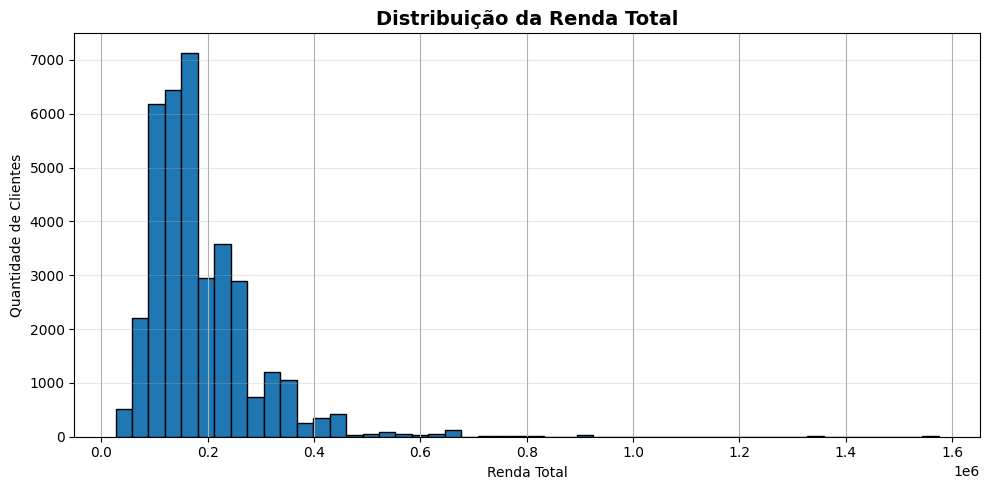

In [ ]:
#identificando graficamente a distribuição de dados da renda
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df_modelb['AMT_INCOME_TOTAL'].hist(
    bins=50,
    edgecolor='black'
)

plt.title('Distribuição da Renda Total', fontsize=14, fontweight='bold')
plt.xlabel('Renda Total')
plt.ylabel('Quantidade de Clientes')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

```
# Observações:
1- Concentração em renda abaixo de 20 mil mas com alguns clientes ganhando até 100 mil
```


In [ ]:
# Foi aplicada transformação logarítmica à variável de renda para reduzir sua assimetria.
import numpy as np

df_modelb['AMT_INCOME_TOTAL_LOG'] = np.log1p(df_model['AMT_INCOME_TOTAL'])

In [ ]:
df_modelb.head()

,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,...,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Not reported,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,AMT_INCOME_TOTAL_LOG
0,1,1,0,427500.0,1,0,0,2.0,32.9,12.435318,...,0,0,1,0,0,0,0,0,0,12.965712
1,1,1,0,427500.0,1,0,0,2.0,32.9,12.435318,...,0,0,1,0,0,0,0,0,0,12.965712
2,1,1,0,112500.0,0,0,0,2.0,58.8,3.104723,...,0,0,0,0,0,0,0,1,0,11.630717
3,0,1,0,270000.0,0,1,1,1.0,52.3,8.353183,...,0,0,0,0,0,1,0,0,0,12.506181
4,0,1,0,270000.0,0,1,1,1.0,52.3,8.353183,...,0,0,0,0,0,1,0,0,0,12.506181


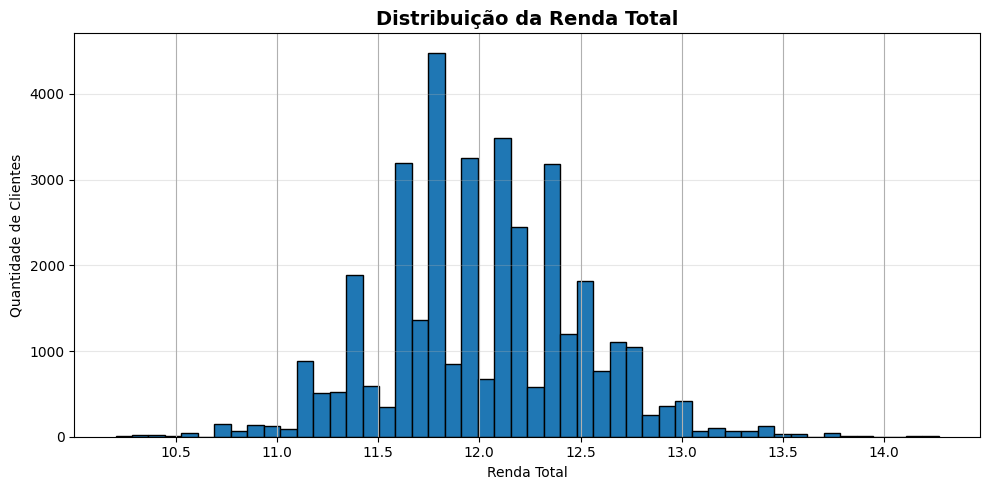

In [ ]:
#identificando graficamente a distribuição de dados da renda na escala logarítmica
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df_modelb['AMT_INCOME_TOTAL_LOG'].hist(
    bins=50,
    edgecolor='black'
)

plt.title('Distribuição da Renda Total', fontsize=14, fontweight='bold')
plt.xlabel('Renda Total')
plt.ylabel('Quantidade de Clientes')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

```
# Observações:
1- renda total balanceada no histograma pela escala logarítmica
```

In [ ]:
#-excluir a variável AMT_INCOME_TOTAL(RENDA) do modelo e deixar apenas o seu correspondente AMT_INCOME_TOTAL_LOG
df_modelc = df_modelb.drop(columns=['AMT_INCOME_TOTAL']).copy()

In [ ]:
df_modelc.head()

,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,TARGET,...,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Not reported,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,AMT_INCOME_TOTAL_LOG
0,1,1,0,1,0,0,2.0,32.9,12.435318,0,...,0,0,1,0,0,0,0,0,0,12.965712
1,1,1,0,1,0,0,2.0,32.9,12.435318,0,...,0,0,1,0,0,0,0,0,0,12.965712
2,1,1,0,0,0,0,2.0,58.8,3.104723,1,...,0,0,0,0,0,0,0,1,0,11.630717
3,0,1,0,0,1,1,1.0,52.3,8.353183,0,...,0,0,0,0,0,1,0,0,0,12.506181
4,0,1,0,0,1,1,1.0,52.3,8.353183,0,...,0,0,0,0,0,1,0,0,0,12.506181


In [ ]:
#verificando a correlação entre a quantidade de membros da família e a quantidade de filhos
df_model[
    ['CNT_CHILDREN',
     'CNT_FAM_MEMBERS']
].corr()

,CNT_CHILDREN,CNT_FAM_MEMBERS
CNT_CHILDREN,1.000000,0.889114
CNT_FAM_MEMBERS,0.889114,1.000000


In [ ]:
#excluindo CNT_FAM_MEMBERS do modelo para deixar apenas CNT_CHILDREN
df_modeld = df_modelc.drop(columns=['CNT_FAM_MEMBERS']).copy()

In [ ]:
df_modeld.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 52 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   FLAG_OWN_CAR                                       36457 non-null  int64  
 1   FLAG_OWN_REALTY                                    36457 non-null  int64  
 2   CNT_CHILDREN                                       36457 non-null  int64  
 3   FLAG_WORK_PHONE                                    36457 non-null  int64  
 4   FLAG_PHONE                                         36457 non-null  int64  
 5   FLAG_EMAIL                                         36457 non-null  int64  
 6   AGE                                                36457 non-null  float64
 7   YEARS_EMPLOYED                                     36457 non-null  float64
 8   TARGET                                             36457 non-null  int64  
 9   CODE_G